# CREATE DATA OBJECT TWOPData to load ALL recording data


## The data basepath should contain
    - INTAN FILES
        - info.rhd
        - one of the following: amplifier_analogin_auxiliary_int16.dat, analogin.dat, (basename).dat

    - FACEMAP FILES
        - a ..._proc.npy file or ..._proc.mat file

    - SUITE2P FOLDER
        - folder containing preprocessed 'suite2p' folder
        - Experiment.xml file (containing scope fps, optional) -> can provide manually if you dont have

In [1]:
## Import data wrapper from main file 
from twop_pipeline.TwoPDataPipeline import TwoPData
import os 
%load_ext autoreload
%autoreload 2

# time to run tutorial
import time
start_time = time.time()
# path to directory that contains all data files from recording
#data_basepath = '/mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1'
data_basepath = '/mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1'
# encapsulate and load data (intan signals, facemap, and suite2p outputs) into all_data variable for analysis use 
# if using default channels for 2P recordings, can just call 
#                                              all_data = TwoPData(data_basepath)
# when scope_fps is None, get scope fps from Experiment.xml file, else est from scope times
all_data = TwoPData(suite2p_basepath=data_basepath, intan_basepath=data_basepath, facemap_path=data_basepath,
                    twop_channel=2, pd_channel=5,
                      camera_channel=3, treadmill_channel=6, scope_fps=None)

ModuleNotFoundError: No module named 'twop_pipeline'

Example 2

Found Suite2P Path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10/suite2p!
Found scope fps from Experiment.xml file: 29.16

Reading Intan Technologies RHD Data File, Version 1.5

Found 3 amplifier channels.
Found 0 auxiliary input channels.
Found 0 supply voltage channels.
Found 3 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.



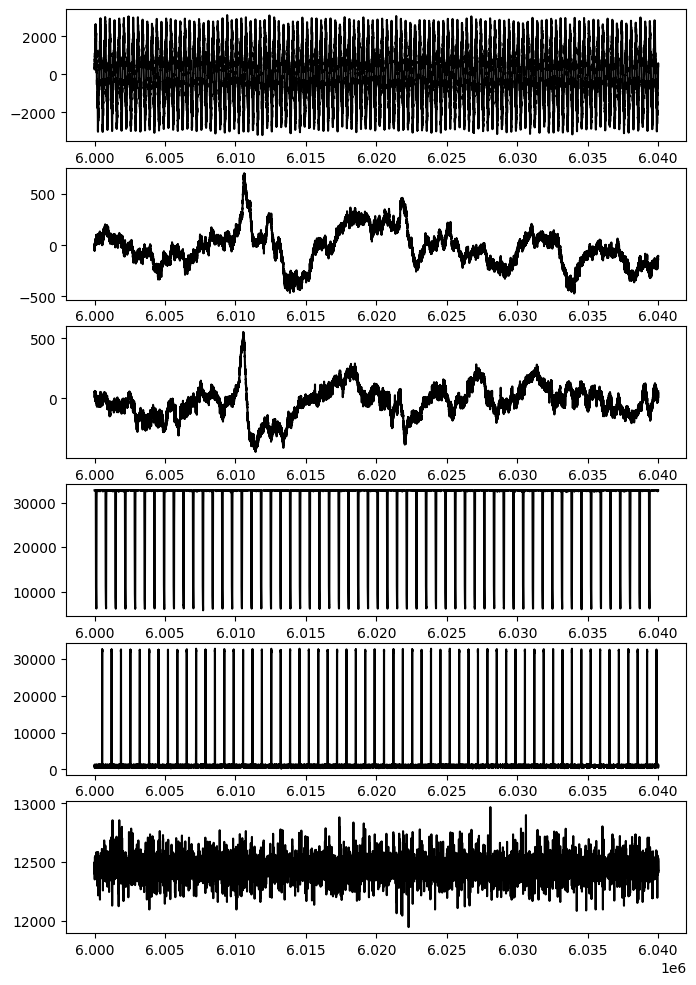

Getting transitions from 0:1291.10395 s
Found 36000 raw triggers for scope
Aligning triggers... 36000 scope times and 35999 s2p frames
Getting transitions from 0:1291.10395 s
Found 38476 raw triggers for camera
Found facemap file path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10/viptiger_backleft_p10_2025-08-13-194906-0000_proc.npy


In [2]:
vip_basepath = '/mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10'
# when plot_intan = True, shows a plot visualizing analog signals per channel
vip_data = TwoPData(suite2p_basepath=vip_basepath, intan_basepath=vip_basepath, facemap_path=vip_basepath,
                    twop_channel=3, camera_channel=4, plot_intan=True, intan_plot_start_s=300, intan_plot_end_s=302)

##### Save class to joblib to save time reloading all data later
alternatively, you can use other serialization libraries for reloading such as pickle or pydantic 

In [3]:
import joblib, os

data_output = os.path.join(data_basepath, 'twopdata.joblib')
if not os.path.exists(data_output):
    joblib.dump(all_data, data_output, compress=("lz4", 3))

##### Reload joblib file

In [4]:
# if os.path.exists(data_output):
#     all_data = joblib.load(data_output)

### Ex. Get a raw intan signal and its timings

##### Camera

In [5]:
camera_signal = all_data.camera_raw
camera_times = all_data.camera_times
print(f'Camera signal raw: {camera_signal}')
print(f'Camera trigger times: {camera_times}')

Camera signal raw: [3.24195561 3.29029641 3.29996457 ... 3.28385097 3.29996457 3.26693169]
Camera trigger times: [  31.2491    31.28505   31.32125 ... 7683.62565 7683.65895 7683.6923 ]


##### Treadmill

In [6]:
treadmill_signal = all_data.treadmill_raw
print(f'Treadmill signal raw: {treadmill_signal}')

Treadmill signal raw: [1.25605512 1.25202672 1.25202672 ... 1.2568608  1.2548466  1.25605512]


##### Scope

In [7]:
scope_signal = all_data.twop_raw
scope_times = all_data.scope_times
print(f'Raw 2P analog: {scope_signal}')
print(f'Scope trigger times: {scope_times}')

Raw 2P analog: [0.         0.         0.         ... 0.00040284 0.         0.        ]
Scope trigger times: [  40.6442    41.37605   42.108   ... 7650.79205 7651.524   7652.25595]


##### Photodiode

In [8]:
pd_signal = all_data.photodiode_raw
pd_times = all_data.pd_times
print(f'Photodiode signal raw: {pd_signal}')
print(f'Photodiode times: {pd_times}')

Photodiode signal raw: [0.26506872 0.26265168 0.26104032 ... 0.2598318  0.26104032 0.261846  ]
Photodiode times: [  60.3388    61.2286    61.23265 ... 7337.71155 7340.2301  7342.72785]


##### Ex. reading intan data independent of TwoData class (this is already done internally upon instantiation of a TwoPData object)


Reading Intan Technologies RHD Data File, Version 1.5

Found 0 amplifier channels.
Found 0 auxiliary input channels.
Found 0 supply voltage channels.
Found 8 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.



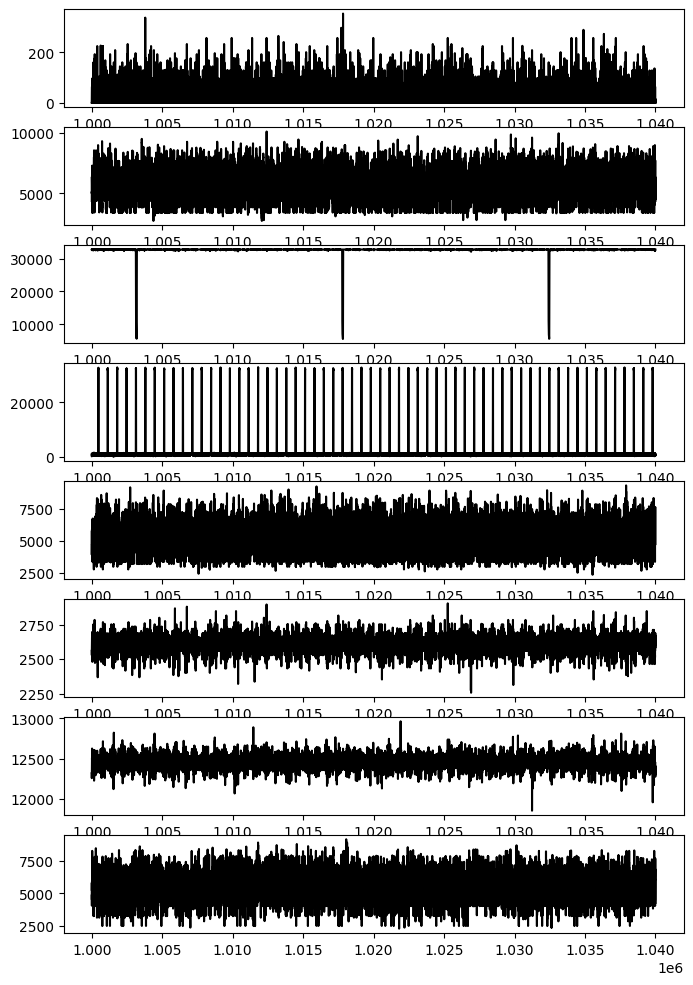

In [9]:
# for header reading, plotting, and extracting directly 
from twop_pipeline.utils.getDataFiles import get_all_intan_data

fs_intan, photodiode_raw_0, twop_raw_0, camera_raw_0, treadmill_raw_0 = get_all_intan_data(intan_basepath=data_basepath, 
                                                                                   twop_chan=2, pd_chan=5, camera_chan=3, treadmill_chan=6,
                                                                                   plot_intan=True, intan_plot_start_s= 50, intan_plot_end_s= 52)

## Get suite2p object from TwoPData
(created from class definition in getSuite2POutput)

In [10]:
suite2p_output = all_data.s2p_out

### Ex. creating a suite2p object independent of TwoData class (this is already done internally upon instantiation of a TwoPData object)

In [11]:
from twop_pipeline.twop.getSuite2POutput import Suite2POutput

s2p_standalone_obj = Suite2POutput(suite2p_path=data_basepath)

Found Suite2P Path /mnt/Gianna_Mattessich/Arenski_Data/NGF_MMN/WT/WT7628/WT7628_day1/field_depth20um/suite2p!
Found scope fps from Experiment.xml file: 1.366


### Ex. get ΔF/F traces and save to CSV

In [12]:
import os 

deltaF_savepath = os.path.join(data_basepath, 'deltaF.csv')
# calc deltaF without saving -> 
#                              dff = suite2p_output.calc_deltaF(), see other possible params in getSuite2POutput.py

# deltaF function returns both dff array and estimated time array (1D). To get only dff, specify index 0 when defining
# get deltaF as numpy array
deltaF = suite2p_output.calc_deltaF(save_csv=deltaF_savepath)[0]

# load as dataframe
deltaF_dataframe = suite2p_output.calc_deltaF(output_df=True)[0]

# get neuropil spikes (optional)
deltaF_neuropils = suite2p_output.calc_deltaF(F_neuropil=True)[0]

deltaF_neuropils_dataframe = suite2p_output.calc_deltaF(F_neuropil=True, output_df=True)[0]

In [13]:
deltaF_dataframe.head().iloc[:, 0:5]

,0,1,2,3,4
0,0.000000,0.732064,1.464129,2.196193,2.928258
1,-0.083254,0.001216,0.079579,0.102273,0.012275
2,0.019921,0.296256,0.280696,0.007841,0.079952
3,0.075467,0.114184,0.126733,0.175848,0.088120
4,-0.023879,0.652193,0.333986,0.136503,0.097814


In [14]:
deltaF_neuropils_dataframe.head().iloc[:, 0:5]

,0,1,2,3,4
0,0.000000,0.732064,1.464129,2.196193,2.928258
1,-0.192842,0.017124,0.055907,0.244451,0.022444
2,0.035426,0.473022,0.442829,-0.004641,0.168350
3,0.131629,0.171367,0.178327,0.241303,0.117538
4,-0.021765,2.509089,1.147232,0.671692,0.454902


### Ex. get cell spikes

In [15]:
spikes_savepath = os.path.join(data_basepath, 'spikes.csv')
# get array of spikes and save to csv
spikes_arr = suite2p_output.get_cell_spikes(save_to_csv=True, output_filepath= spikes_savepath)
# get dataframe of spikes -> (num_cells, num_frames) when output_df = True
spikes_df = suite2p_output.get_cell_spikes(output_df=True)

In [16]:
# inspect dataframe
spikes_df.head().iloc[:, 0:5]

,0,1,2,3,4
0,0.0,50.765545,12.826757,22.856503,0.0
1,0.0,482.167542,0.000000,0.000000,0.0
2,0.0,78.417122,39.992268,51.504822,0.0
3,0.0,650.387573,0.000000,0.000000,0.0
4,0.0,19.674032,0.000000,0.000000,0.0


### Ex. get raw fluorescence, num cells, etc

In [17]:
print(f'Raw fluourescence {suite2p_output.F}')
print(f'Number cells {suite2p_output.num_cells}')

Raw fluourescence [[ 667.4568   723.71606  776.35187 ...  761.26544  821.4877   821.4877 ]
 [1036.7976  1288.4706  1274.3833  ... 1186.7699  1256.8241  1256.8241 ]
 [ 827.5935   855.89923  865.1357  ...  808.67596  910.91565  910.91565]
 ...
 [ 336.1732   340.5882   314.1919  ...  288.02185  314.32724  314.32724]
 [ 397.5971   411.43158  420.15482 ...  345.8997   348.80142  348.80142]
 [ 534.19476  621.2366   563.6658  ...  567.9311   404.02505  404.02505]]
Number cells 22


### Ex. calculate SNR

In [18]:
SNR = suite2p_output.get_SNR()
SNR

array([8.19631156, 4.92604073, 7.10638876, 5.9059258 , 6.32393358,
       6.95784123, 6.51636019, 6.16092114, 5.57617627, 5.96948139,
       5.78130782, 4.94434196, 5.51368487, 5.71862928, 4.37150727,
       5.35913393, 6.27719698, 5.31683845, 5.41480537, 5.16645741,
       5.69824067, 5.78965222])

### Ex. make some plots

(<Figure size 6000x500 with 5 Axes>,
 array([<Axes: ylabel='Cell 5'>, <Axes: ylabel='Cell 6'>,
        <Axes: ylabel='Cell 7'>, <Axes: ylabel='Cell 8'>,
        <Axes: xlabel='Frame', ylabel='Cell 9'>], dtype=object))

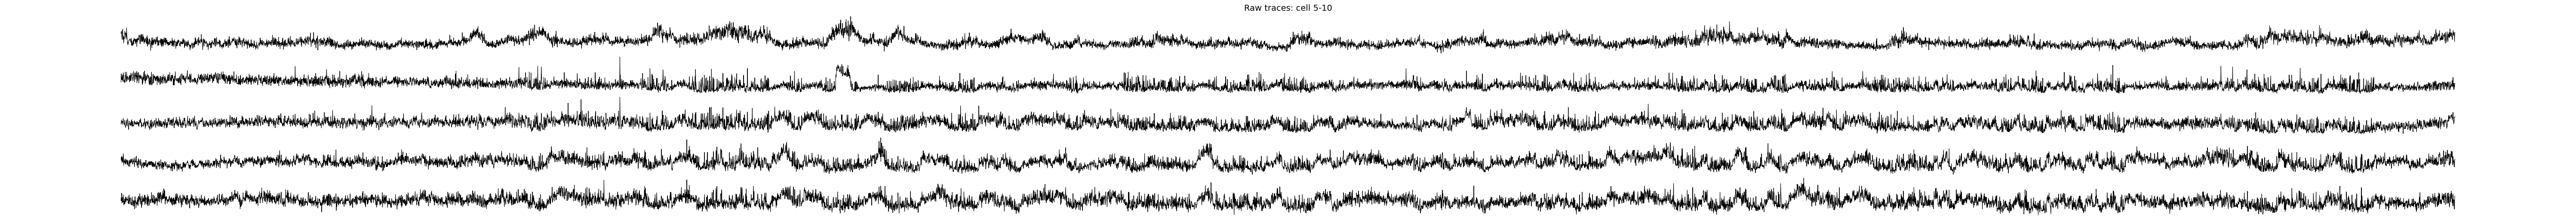

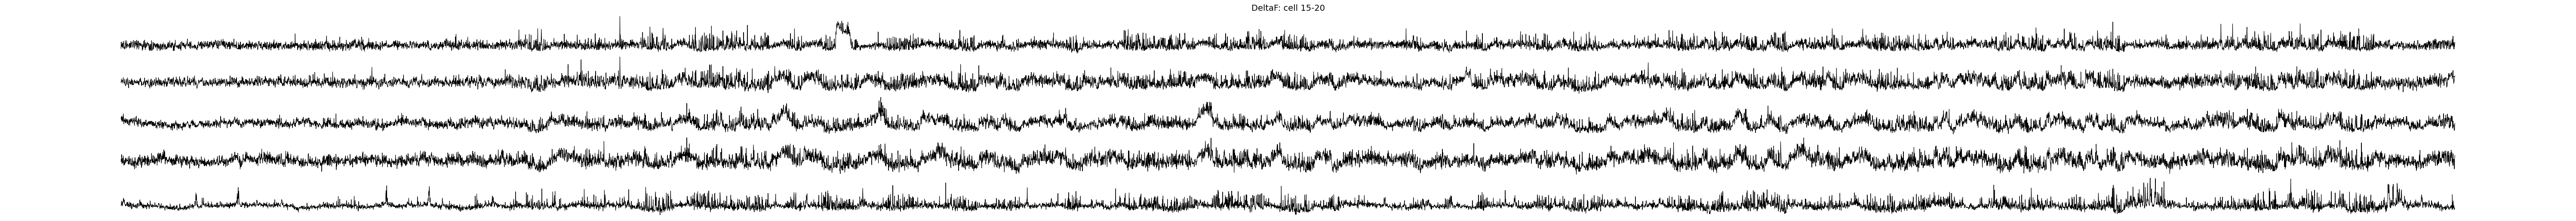

In [19]:
from twop_pipeline.twop.plots import *

# can specify cell range to plot
plot_raw_traces(suite2p_output, cell_range=[5,10], title='Raw traces: cell 5-10',**{'figsize':(60,5)})
plot_dff(suite2p_output, cell_range=[5, 10], title='DeltaF: cell 15-20',**{'figsize':(60,5)})

(<Figure size 6000x500 with 5 Axes>,
 array([<Axes: ylabel='Cell 0'>, <Axes: ylabel='Cell 1'>,
        <Axes: ylabel='Cell 2'>, <Axes: ylabel='Cell 3'>,
        <Axes: xlabel='Frame', ylabel='Cell 4'>], dtype=object))

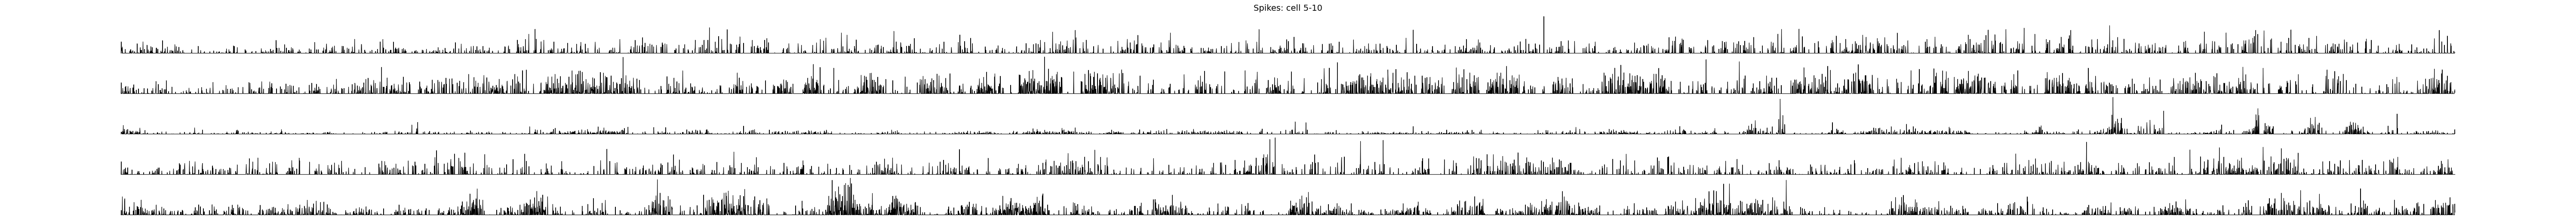

In [20]:
plot_spikes(suite2p_output, cell_range=[0, 5], title='Spikes: cell 5-10',**{'figsize':(60,5)})

<Axes: title={'center': 'Smoothed heatmap'}, xlabel='Frame (#)', ylabel='Cell (#, relative in range)'>

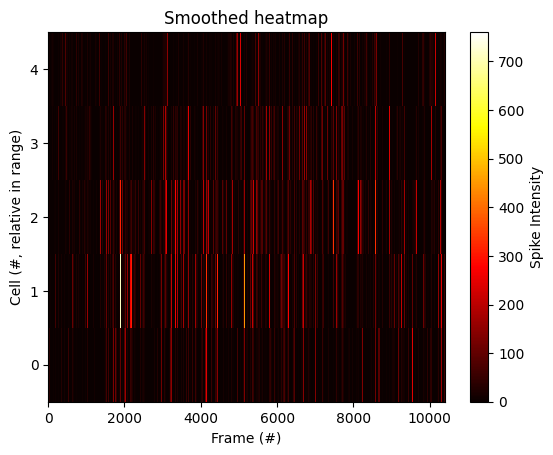

In [ ]:
smoothed_event_plot(suite2p_output, cell_range=[5, 10], title='Smoothed heatmap')

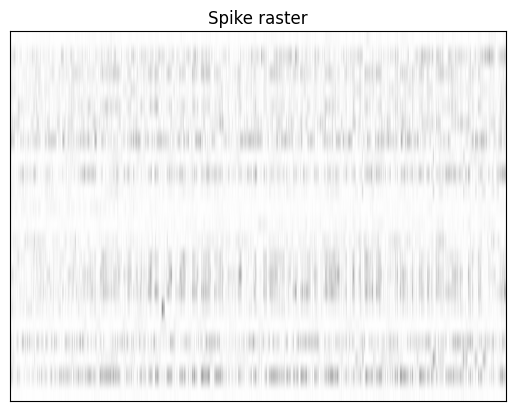

<Axes: title={'center': 'Spike raster'}>

In [22]:
spike_raster(suite2p_output, title='Spike raster')

### Get a frame dataframe with estimated relative time since t0 and raw scope times in seconds since recording start

In [23]:
frame_df_out = os.path.join(data_basepath, 'frame_df.csv')
frame_df = all_data.make_frame_df(output_csv= False, output_filepath= frame_df_out)
frame_df

,timeEst,frame_time
0,0.000000,40.64420
1,0.732064,41.37605
2,1.464129,42.10800
3,2.196193,42.83995
4,2.928258,43.57190
...,...,...
10395,7609.809663,7649.32815
10396,7610.541728,7650.06010
10397,7611.273792,7650.79205
10398,7612.005857,7651.52400


### Ex. get raw facemap dict output

In [24]:
## Get facemap data dict in isolation
from twop_pipeline.utils.getDataFiles import get_facemap_data
facemap_data = get_facemap_data(vip_basepath)

# accessing from data object
all_data.facemap_data

Found facemap file path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10/viptiger_backleft_p10_2025-08-13-194906-0000_proc.npy


{'filenames': [['/mnt/Batista_Lab/Arenski/2p_22q_lamp5/WT7628/WT7628_day1/WT7628_10_21_24_Lamp5GCamp_V1_MMN/WT7628_10_21_24_Lamp5GCamp_V1_MMN_face_2024-10-21-155230-0000.avi']],
 'save_path': '/mnt/Batista_Lab/Arenski/2p_22q_lamp5/WT7628/WT7628_day1/WT7628_10_21_24_Lamp5GCamp_V1_MMN',
 'Ly': [482],
 'Lx': [644],
 'sbin': 4,
 'fullSVD': False,
 'save_mat': True,
 'Lybin': array([120], dtype=int32),
 'Lxbin': array([161], dtype=int32),
 'sybin': array([0]),
 'sxbin': array([0]),
 'LYbin': 120,
 'LXbin': 161,
 'avgframe': [array([[60.42169 , 53.488995, 49.087685, ..., 51.704308, 51.863434,
          52.164192],
         [48.28631 , 45.272377, 46.113064, ..., 48.88519 , 48.167187,
          49.80181 ],
         [42.576683, 41.035   , 42.309246, ..., 47.097813, 46.018   ,
          46.261753],
         ...,
         [ 9.778375,  9.856188, 10.736375, ..., 35.09162 , 33.840374,
          33.922188],
         [ 9.768187,  9.75    , 10.394625, ..., 35.634   , 34.48281 ,
          33.763123],
  

### Get a state dataframe with camera aligned times and state values

In [25]:
import twop_pipeline.state.getFacemapData as fmd

###TWO WAYS TO CALL

# 1. directly from getFacemapData file (also defined internally in TwoPData)
from twop_pipeline.utils.alignmentFunctions import get_analog_times
camera_times, camera_times_end = get_analog_times(camera_raw_0) # signal derived from get_all_intan_data in utils.getDataFiles
state_dataframe_0 = fmd.get_state_df(facemap_data, camera_times, pupil_data=False, 
                                  movement_percentile=70, min_duration_s=1.25,
                                    min_max_norm=False, annotate_state=False)

# 2. (PREFERRED) from twopdata
print('MAKING STATE DF FROM all_data!')
state_dataframe = all_data.make_state_df(min_duration_s=1.25, min_max_norm=True)
state_dataframe.head()

Getting transitions from 0:7691.47195 s
Found 229569 raw triggers
Estimated camera FPS ≈ 29.985
Facemap motion signal contains 38473 frames, camera captured 229569 frames.
Threshold for face motion: 46.551191705431144
motion_bool True ratio: 0.1756683175864337
MAKING STATE DF FROM all_data!
Facemap motion signal contains 229244 frames, camera captured 229569 frames.
Threshold for face motion: 9449.699160553104
motion_bool True ratio: 0.2220508866615266
Threshold for treadmill: 1.255951699294335


,time,motion_bool,locomotion_bool,motion,treadmill,state
0,31.24910,False,False,0.319375,1.254825,unaroused
1,31.28505,False,False,0.313664,1.254753,unaroused
2,31.32125,False,False,0.302549,1.253095,unaroused
3,31.35580,False,False,0.286630,1.255373,unaroused
4,31.38975,False,False,0.266764,1.254287,unaroused


#### Ex. get state dataframe with pupil data

In [26]:
# get dataframe min max normed and annotated with quiet awake as well
state_dataframe_pupil = all_data.make_state_df(pupil_data=True, movement_percentile=70, min_duration_s=1.25, min_max_norm=True, annotate_state_with_pupil=True)
state_dataframe_pupil.head()

Facemap motion signal contains 229244 frames, camera captured 229569 frames.
Threshold for face motion: 9449.699160553104
motion_bool True ratio: 0.2220508866615266
Threshold for treadmill: 1.255951699294335
Threshold for pupil: 2306.9980761224006


,time,motion_bool,locomotion_bool,pupil_bool,motion,treadmill,pupil_area,state
0,31.24910,False,False,True,0.319375,1.254825,0.602582,unaroused
1,31.28505,False,False,True,0.313664,1.254753,0.602820,unaroused
2,31.32125,False,False,True,0.302549,1.253095,0.603264,unaroused
3,31.35580,False,False,True,0.286630,1.255373,0.603854,unaroused
4,31.38975,False,False,True,0.266764,1.254287,0.604518,unaroused


#### Ex. get state dataframe with paw data

In [27]:
# IMPORTANT: if paw_data == True you need to provide motion indices as a dictionary where the keys are the svd type, and the values are the index of that SVD
# possible keys: 'motion','left_paw','right_paw'
# if use_motsvd == True, get motion signal from SVD, NOT from motion key in facemap data
# in this case use_motsvd == False and motion signal will be derived from index in 'motion' key
state_dataframe_paw = vip_data.make_state_df(paw_data=True, motion_indices={'motion':1, 'left_paw':1, 'right_paw':2}, annotate_state=False)
state_dataframe_paw.head()

Facemap motion signal contains 38473 frames, camera captured 38476 frames.
Threshold for face motion: 46.551191705431144
motion_bool True ratio: 0.20602453477492463
Getting paw data....
Threshold for left paw: 0.005987418650265656
Got data for left paw!
Threshold for right paw: -0.058329581017254405
Got data for right paw!
Adding left paw data


,time,motion_bool,motion,left_paw,left_paw_bool,right_paw,right_paw_bool
0,4.64505,False,0.197854,0.203748,False,0.374835,False
1,4.68100,False,0.191437,0.206761,False,0.374812,False
2,4.71725,False,0.179260,0.212412,False,0.374757,False
3,4.75285,False,0.162529,0.220038,False,0.374652,False
4,4.78715,False,0.142817,0.228824,False,0.374475,False


In [28]:
start, end = 1000, 1200
time_range = state_dataframe_pupil[(state_dataframe_pupil['time'] > start) & (state_dataframe_pupil['time'] < end)]
motion = time_range['motion']

print(motion)
np.mean(motion)

29062    0.008184
29063    0.008498
29064    0.008911
29065    0.009386
29066    0.009879
           ...   
35057    0.008033
35058    0.008333
35059    0.008602
35060    0.008810
35061    0.008931
Name: motion, Length: 6000, dtype: float64


0.0896526367859135

### Plot a state timeline

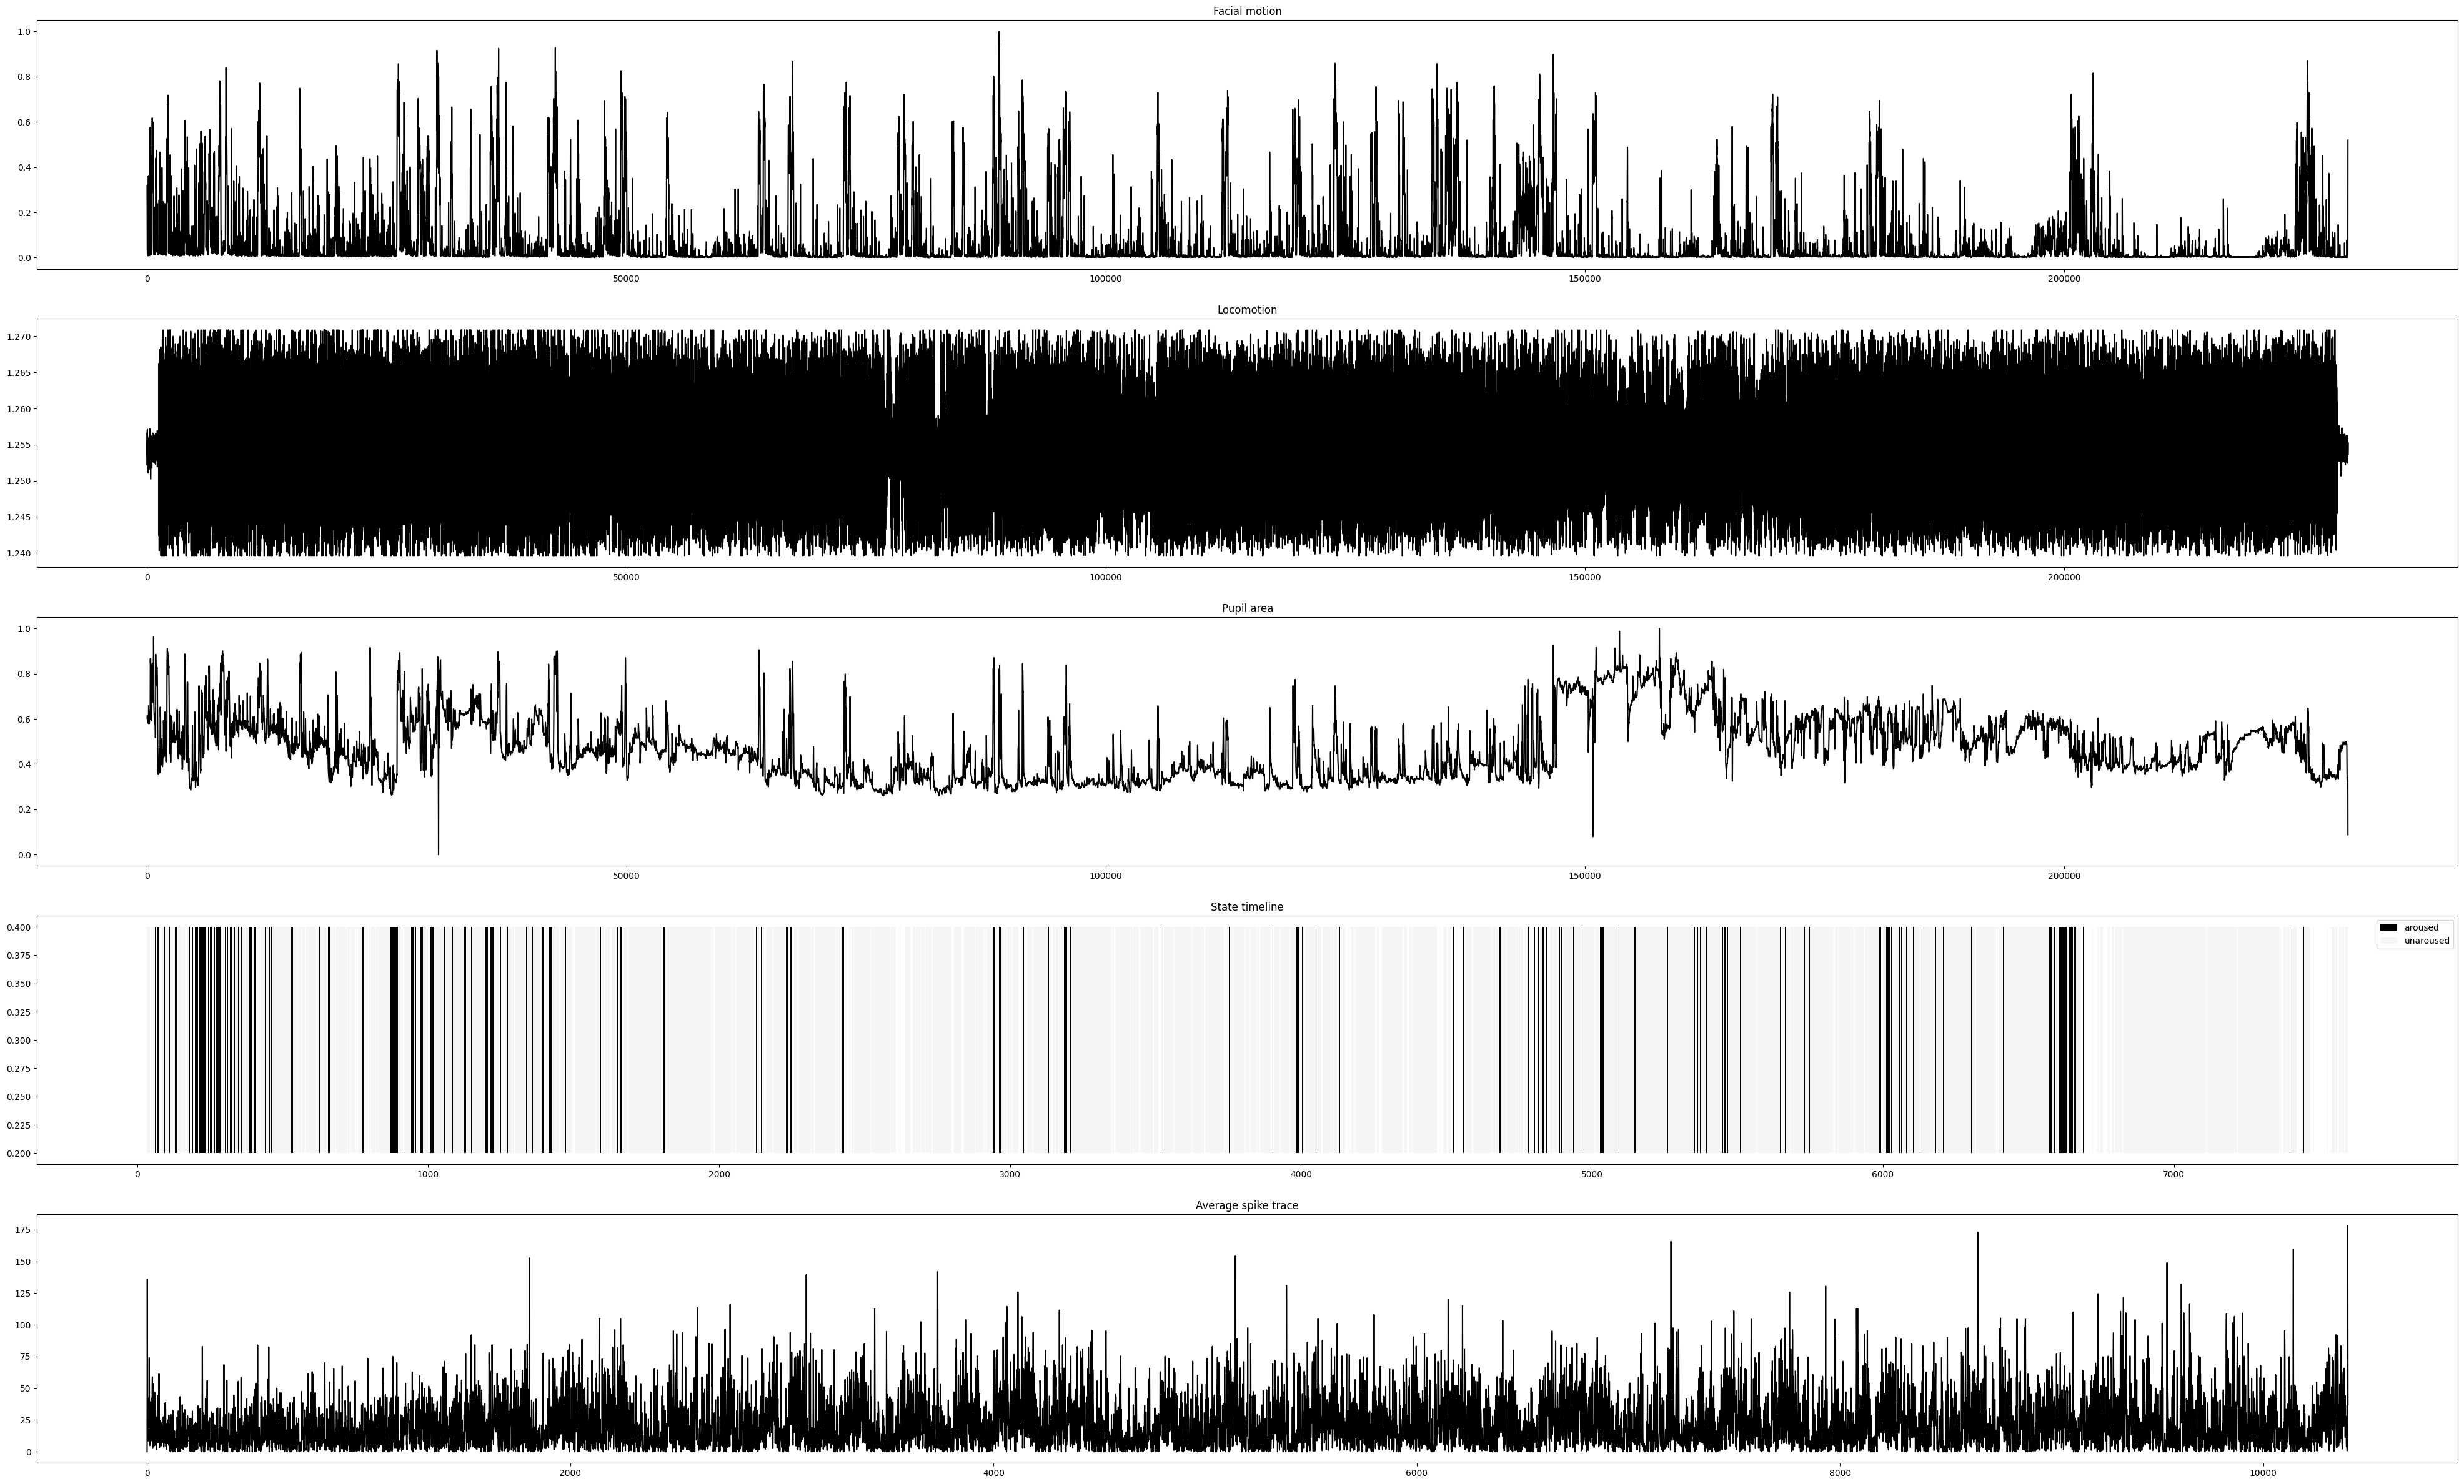

In [29]:
from twop_pipeline.state.extractStates import plot_state_timeline

plot_state_timeline(state_dataframe_pupil, spikes_arr.mean(axis=0))


### Get a frame aligned state dataframe, including nearest frames at camera times

In [30]:
frame_state_df = all_data.frame_state_df(state_dataframe)
# to output csv ->
# frame_state_df = all_data.frame_state_df(state_dataframe, output_csv=True)
frame_state_df.head()

,time,nearest_frame_idx,frame_start_time,motion_bool,motion,treadmill,locomotion_bool
0,31.24910,0,40.6442,False,0.319375,0.487574,False
1,31.28505,0,40.6442,False,0.313664,0.485285,False
2,31.32125,0,40.6442,False,0.302549,0.432335,False
3,31.35580,0,40.6442,False,0.286630,0.505076,False
4,31.38975,0,40.6442,False,0.266764,0.470404,False


#### Get a motion signal resampled to frame triggers 

In [31]:
# get motion from state dataframe. can also access with all_data.facemap_data['motion'][1]
motion = state_dataframe['motion'].to_numpy()
frame_times = all_data.scope_times
motion

array([0.31937477, 0.31366387, 0.30254901, ..., 0.46720954, 0.50136321,
       0.51936523])

In [32]:
from twop_pipeline.utils.alignmentFunctions import *

motion_resampled = motion_to_2p_bins(frame_times, motion=motion, motion_times=state_dataframe['time'])
motion_resampled

array([0.03939618, 0.08237943, 0.42840612, ..., 0.00384523, 0.00284901,
       0.00292976])

#### Get a categorical signal resampled to frame triggers (can use for interpolating states)

In [33]:
states = state_dataframe['state']
states_resampled = categorical_to_2p(frame_times=frame_times, state_values=states, state_times=state_dataframe['time'])
states_resampled

array(['unaroused', 'unaroused', 'aroused', ..., 'unaroused', 'unaroused',
       'unaroused'], dtype=object)

## Motion correlations

### Get per-cell motion/spike correlation

In [34]:
from twop_pipeline.state.motionCorrelations import *

dff = suite2p_output.calc_deltaF()[0]
spikes = suite2p_output.get_cell_spikes()

print(f'dff corr: {corr_motion_dff(dff, motion_resampled)}')
print(f'spikes corr: {corr_motion_dff(spikes, motion_resampled)}')

dff corr: [-0.07265714  0.06642827 -0.03577347  0.07722599 -0.08419573 -0.09511333
 -0.01414729 -0.10212847 -0.07069215  0.15046972 -0.07664864 -0.03030287
  0.02680447  0.08212971  0.08726657  0.00662403 -0.07030349 -0.03097562
 -0.03915189  0.04387729 -0.05613835 -0.07807097]
spikes corr: [-0.06322062  0.03233852 -0.01713733  0.04096379 -0.05283809 -0.04100569
  0.00986859 -0.04229759 -0.02376995  0.10261279 -0.04390218 -0.00521986
  0.03819338  0.0383295   0.03408056 -0.01921286 -0.02605976 -0.00497632
 -0.0381717   0.06560038 -0.03638916 -0.007786  ]


### Find motion onsets

In [35]:
from twop_pipeline.state.motionCorrelations import find_motion_onsets
find_motion_onsets(motion_resampled, frame_times)

array([    1,     8,    23,    28,    36,    44,    48,    56,    64,
          69,    74,    79,    90,    93,   101,   104,   111,   115,
         118,   126,   132,   138,   144,   149,   156,   164,   178,
         182,   198,   207,   212,   218,   221,   232,   237,   242,
         248,   254,   258,   268,   271,   278,   290,   296,   300,
         303,   314,   318,   325,   340,   359,   373,   386,   398,
         404,   411,   423,   429,   441,   462,   472,   476,   488,
         495,   507,   512,   530,   534,   538,   543,   551,   556,
         565,   589,   602,   606,   642,   648,   653,   674,   687,
         698,   710,   730,   738,   757,   762,   775,   789,   795,
         798,   804,   829,   842,   854,   877,   880,   895,   898,
         901,   917,   920,   948,   952,   964,   972,   982,   989,
         998,  1008,  1013,  1022,  1045,  1048,  1054,  1059,  1065,
        1068,  1073,  1080,  1084,  1102,  1112,  1132,  1141,  1153,
        1159,  1174,

### Spike triggered average: compute and plot

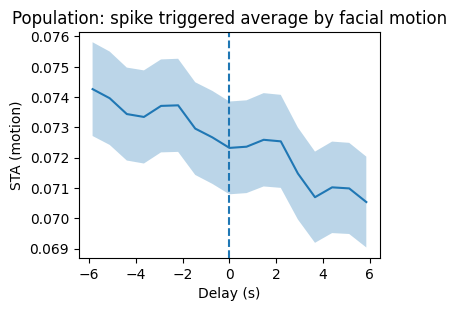

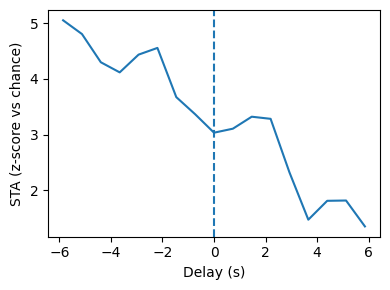

In [36]:
tau, sta_mean, sta_sem, z_sta = spike_triggered_average_motion(
    spikes, frame_times, motion_resampled)

plot_sta(tau, sta_mean, sta_sem, z_sta=z_sta)

### Motion triggered average: compute and plot

<Axes: title={'center': 'Per-cell motion-triggered average'}, xlabel='Time from motion onset (s)', ylabel='Cells (sorted)'>

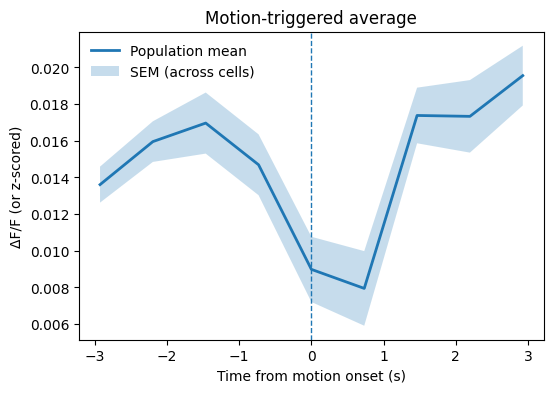

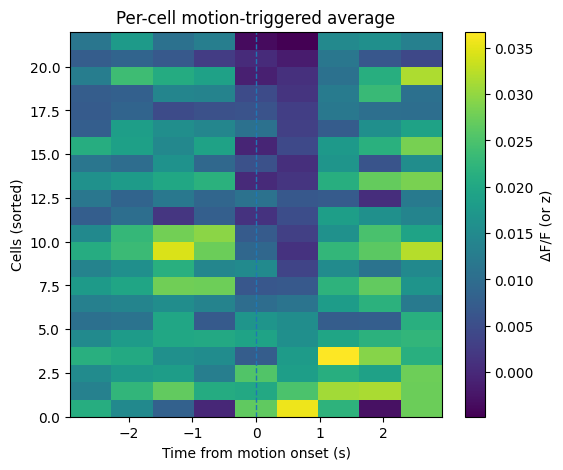

In [37]:
time_win, mta_pop, mta_cells, onsets = compute_mta(dff, frame_times, motion_resampled)
plot_mta_population(time_win, mta_pop, mta_cells)
plot_mta_heatmap(time_win, mta_cells)

### Compute per cell AUROC for motion

In [39]:
compute_auroc_motion_per_cell(dff, motion_resampled)

(array([0.46546809, 0.54340502, 0.48417703, 0.5338402 , 0.45342811,
        0.43850621, 0.49773478, 0.43713388, 0.45498815, 0.60804797,
        0.45582453, 0.4894396 , 0.53646583, 0.56390602, 0.56723792,
        0.51010572, 0.46589601, 0.48254727, 0.48911026, 0.5392633 ,
        0.48243155, 0.45577929]),
 array([0., 1., 1., ..., 0., 0., 0.]))

## LFP Functions

In [40]:
from twop_pipeline.lfp.readLFP import *
from twop_pipeline.lfp.lfpFunctions import *

# extract lfp and flush to memory
extract_lfp(basepath=vip_basepath, channels=[1, 2])

# load back from memory
vip_lfp = load_lfp(lfp_source = os.path.join(vip_basepath, f'{os.path.basename(vip_basepath)}.lfp'))
vip_lfp

CuPy not available — using CPU fallback.

Reading Intan Technologies RHD Data File, Version 1.5

Found 3 amplifier channels.
Found 0 auxiliary input channels.
Found 0 supply voltage channels.
Found 3 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.

Processing from disk in 13 batches...
LFP extraction complete. Saved to: /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p10/p10.lfp


array([[-56, 110,  63, ..., -14,  11, -22],
       [ 14, -25,  30, ...,   7, -63, -26]], dtype=int16)

In [41]:
from twop_pipeline.lfp.lfpFunctions import *

# compute power spect for 2nd lfp channel
freqs, times, power_db = compute_power_spect_db(vip_lfp[1], fs=1250)

##### Summarize power db for common band values (includes normalized per freq values)

In [42]:
band_summary_dict = summarize_bands(spect_power_db=power_db, f=freqs)
band_summary_dict

{'delta': array([27.1652565 , 27.43893798, 27.46273804, ..., 18.55051653,
        21.90453084, 30.74475384]),
 'delta_z': array([-0.64388059, -0.59728718, -0.5932353 , ..., -2.11051298,
        -1.53950259, -0.03448243]),
 'theta': array([19.97032315, 23.53435121, 21.7809876 , ..., 15.77592058,
        17.50004155, 14.79234838]),
 'theta_z': array([-0.2876195 ,  0.44848764,  0.08635147, ..., -1.15392292,
        -0.79782646, -1.35706793]),
 'alpha': array([16.34731066, 20.49620664, 21.22018087, ..., 14.14614964,
        12.64397192, 13.96960092]),
 'alpha_z': array([ 0.00550574,  0.94906195,  1.11371066, ..., -0.49508987,
        -0.8367203 , -0.53524119]),
 'beta': array([ 8.70325641, 10.89314881, 11.43741638, ..., 10.09954262,
        11.6859404 , 11.12455918]),
 'beta_z': array([-0.46340494,  0.00545781,  0.12198719, ..., -0.16445573,
         0.17519695,  0.05500349]),
 'gamma': array([-1.1319872 ,  1.34014608,  4.01426516, ...,  8.37991471,
         8.70703512,  8.7853518 ]),
 'ga

##### Summarize linear power for band values

In [43]:
summarize_linear_power(power_db, freqs)

{'delta_lin': array([ 765.56129985,  984.95299326,  762.94590534, ...,  132.82845613,
         570.81908922, 1883.86807232]),
 'delta': array([28.83979971, 29.93415504, 28.82493747, ..., 21.23291125,
        27.56498488, 32.75050486]),
 'delta_z': array([-1.05454154, -0.89122116, -1.05675956, ..., -2.18978514,
        -1.24479349, -0.47091224]),
 'theta_lin': array([154.21561389, 273.39733402, 197.08472973, ..., 111.70328213,
        105.78147565,  79.91451098]),
 'theta': array([21.88128347, 24.36794275, 22.94652976, ..., 20.48065934,
        20.24409621, 19.02625646]),
 'theta_z': array([-0.35117422,  0.17662308, -0.12507404, ..., -0.64845887,
        -0.69866976, -0.95715814]),
 'alpha_lin': array([ 57.75611823, 143.99400607, 248.47646007, ...,  26.8143063 ,
         28.5009947 ,  31.14247147]),
 'alpha': array([17.61597997, 21.58344414, 23.95285251, ..., 14.28366566,
        14.54860017, 14.93353075]),
 'alpha_z': array([-0.2027582 ,  0.74160521,  1.30558826, ..., -0.99593882,
    

##### Get dictionary of average values for band

In [44]:
overall_metrics(power_db, freqs)

{'broadband_db': 7.73939619262557,
 'gamma_db': 5.981101788839212,
 'delta_db': 30.947297563723534,
 'theta_db': 21.36289755783798,
 'beta_db': 10.867657292601436,
 'alpha_db': 16.899778220993404,
 'gamma_delta_diff_db': -24.966195774884323,
 'delta_theta_ratio': 9.087407444508974,
 'delta_beta_ratio': 101.85070209765951,
 'theta_gamma_ratio': 34.5286482707296}

##### Calculating linear power ratios

In [45]:
db_to_linear_power(power_db)

array([[2.0693152e+02, 1.6476305e+02, 1.3647382e+03, ..., 8.8609924e+01,
        3.7278268e+02, 2.1608945e+03],
       [1.0154121e+03, 1.1167642e+03, 2.8361346e+02, ..., 1.6669246e+02,
        7.4356519e+02, 1.8933701e+03],
       [7.2271936e+02, 1.5234265e+03, 1.0957921e+03, ..., 6.6005402e+01,
        1.0552277e+03, 2.5231882e+03],
       ...,
       [4.2182364e-02, 1.2222039e-02, 9.5203981e-02, ..., 9.2683429e-01,
        1.3512605e+00, 9.1226006e-01],
       [9.7197838e-02, 2.0675229e-02, 2.0353772e-02, ..., 1.8113948e-01,
        4.5973656e-01, 8.9841032e-01],
       [2.5339991e-01, 5.2494708e-02, 6.2797233e-02, ..., 4.5665376e-02,
        5.6274569e-01, 9.3079197e-01]], dtype=float32)

##### Compute spectrogram and plot

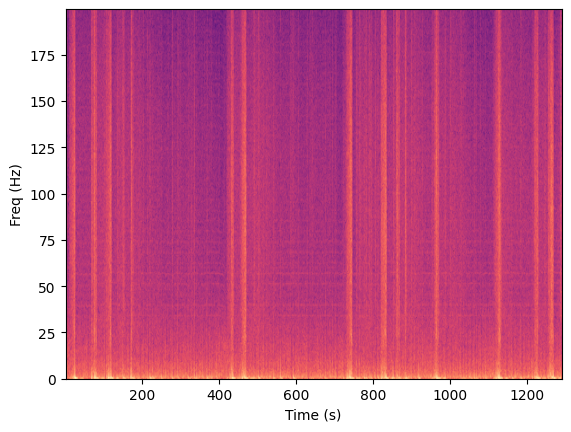

In [46]:
from twop_pipeline.lfp.LFPPlots import *

fig, axs = plt.subplots(1,1)
# NOTE: function assumes that provided spectrogram is already in power db. run compute_power_spect_db for this
plot_LFP_spectrogram(to=times, fo=freqs, spec=power_db, axs=axs, cmap='magma')
plt.show()

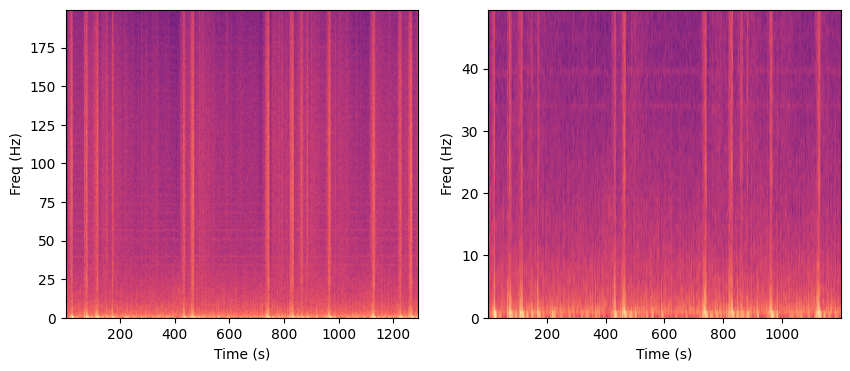

In [47]:
# create multiday spectrogram
freqs_ngf, times_ngf, power_db_ngf  = compute_power_spect_db(vip_lfp[1], fs=1250)
fig_2, axs_sub = plt.subplots(1, 2, figsize=(10, 4))
plot_LFP_spectrogram(to=times, fo=freqs, spec=power_db, axs=axs_sub[0], cmap='magma')
# ex. restrict time axis for second plot
# ex. set fmax for second spectrogram to 50
plot_LFP_spectrogram(to=times_ngf, fo=freqs_ngf, spec=power_db_ngf, axs=axs_sub[1], cmap='magma', t_start=1, t_end=1200, f_max=50)

##### Compute EMG and create plots

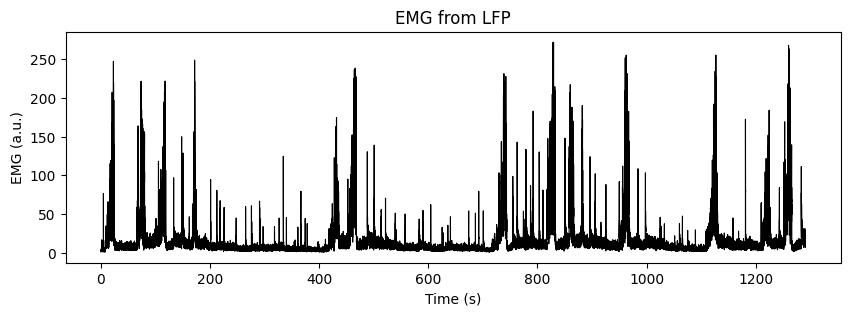

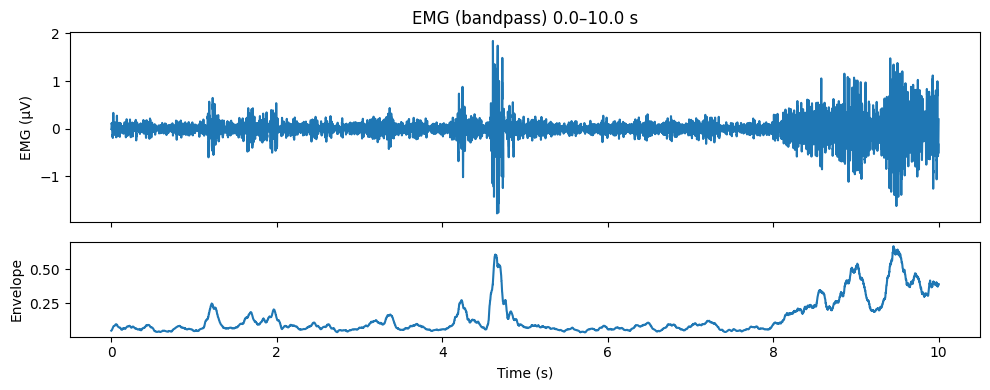

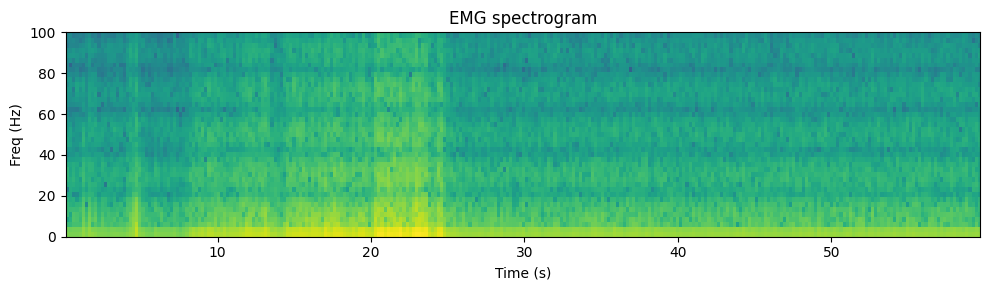

In [57]:
from twop_pipeline.lfp.EMGFromLFP import *

time, emg, emg_per_chan = compute_emg_from_lfp(vip_lfp[1], fs=1250)
emg_bp, emg_rect, emg_env = emg_envelope(emg, fs=1250)
plot_emg_from_lfp(vip_lfp[1], fs=1250)
plot_emg_envelope(emg, fs=1250)
plot_emg_spectrogram(emg, fs=1250)

### Longitudinally tracking cells 

In [11]:
from twop_pipeline.twop.getTrack2POutput import *
from twop_pipeline.twop.getSuite2POutput import *
# provide path containing 'track2p' folder
animal_path = '/mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left'
track2p_out = Track2POutput(animal_path)
# get path of suite2p folder for every recording
s2p_outs = []
for path in os.listdir(animal_path):
    rec_path = os.path.join(animal_path, path, 'suite2p')
    s2p_outs.append(Suite2POutput(rec_path))

Shape of match matrix for cells present: (402, 4) (cells, days)
Found Suite2P Path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p16/suite2p!
Found scope fps from Experiment.xml file: 29.595
Found Suite2P Path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p9/suite2p!
Found scope fps from Experiment.xml file: 29.595
Found Suite2P Path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p17/suite2p!
Found scope fps from Experiment.xml file: 30.043
Found Suite2P Path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p12_stim/suite2p!
Found scope fps from Experiment.xml file: 29.595
Found Suite2P Path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p12/suite2p!
Found scope fps from Experiment.xml file: 29.595
Found Suite2P Path /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/p16_stim/suite2p!
Found scop

ValueError: /mnt/Batista_Lab/Joslyn/Experiments/VIPxTiger/dob_8.3.25/preprocessed/Back_left/track2p-all/suite2p/plane0 is not a valid suite2p path.

Get dictionary of longitudinal cells and their associated trace

In [ ]:
long_cells_dict = track2p_out.get_longitudinal_cells_dict()
long_cells_dict

In [ ]:
track2p_out.get_per_cell_raster(long_cells_dict)

#### Populations: stacking 2D traces for multiple recordings
##### if you want to get population averages, traces will be of different dimensions because of differing recording lengths 
        Case 1: truncate all traces to length of shortest recording
        Case 2: append NaNs to all traces to length of longest recording

In [48]:
# get example spikes from vip data
vip_spikes = vip_data.s2p_out.get_cell_spikes()
print(f'rec 1 shape: {spikes_arr.shape}, rec 2 shape: {vip_spikes.shape}')

rec 1 shape: (22, 10401), rec 2 shape: (156, 36000)


In [49]:
# case 1: truncate 2D traces to total cells X least frames 
    # provide as LIST of traces (not np.array or this will throw error)
restrict_traces([spikes_arr, vip_spikes])

array([[  0.        ,  50.76554489,  12.82675743, ...,   0.        ,
          2.8622961 ,   2.58274293],
       [  0.        , 482.1675415 ,   0.        , ...,  93.96334076,
        177.74382019,  54.12892151],
       [  0.        ,  78.41712189,  39.99226761, ...,   0.        ,
        168.90852356,  18.48920822],
       ...,
       [  0.        ,  26.79074097,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]])

In [50]:
# case 2: pad 2D traces to total cells X most frames 
    # provide as LIST of traces
stack_traces([spikes_arr, vip_spikes])

array([[  0.        ,  50.76554489,  12.82675743, ...,          nan,
                 nan,          nan],
       [  0.        , 482.1675415 ,   0.        , ...,          nan,
                 nan,          nan],
       [  0.        ,  78.41712189,  39.99226761, ...,          nan,
                 nan,          nan],
       ...,
       [  0.        ,  26.79074097,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]])

In [51]:
end_time = time.time()
print(f'Time to run tutorial: {(end_time - start_time)/60} m')

Time to run tutorial: 259.9884397983551
